# Chapter 1: Introduction to Image Datasets

## 1. Introduction to Image Datasets

**Question:**
What do you think the dimensions of an image dataset might look like? How would the shape differ for grayscale and color images?

> **Answer:**  
> There are 4 dimensions of an image dataset, which is:  
> 1.Batch Size 2. width 3. height 4. channels (The depth of color information)  
> For the grayscale images, Dimension Shape would normally be (N,H,W,1), which means each pixel is a single value representing intensity.  
> As For the color images, Dimension Shape would normally be (N,H,W,3), which means each pixel contains three values (Red, Green, Blue).

## 2. Loading an Image Dataset

In this step, you will load the CIFAR-10 dataset using TensorFlow.

**Tasks:**
1. Find the TensorFlow function used to load CIFAR-10.
2. Load the dataset into training and test sets. What are the shapes of the images and labels?
3. How many images are there in the training and test sets? How many classes does CIFAR-10 have?

In [4]:
# Task: Load the CIFAR-10 dataset
import tensorflow as tf
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# x_train: Training Features
# y_train: Training Labels
# x_test: Testing Features
# y_test: Testing Labels
print("traning sets shapes (x_train):", x_train.shape)
print("traning sets labels (y_train):", y_train.shape)
print("testing sets shapes (x_test):", x_test.shape)
print("testing sets labels (y_test):", y_test.shape)

unique_classes = np.unique(y_train)
print("classes number:",  unique_classes)

traning sets shapes (x_train): (50000, 32, 32, 3)
traning sets labels (y_train): (50000, 1)
testing sets shapes (x_test): (10000, 32, 32, 3)
testing sets labels (y_test): (10000, 1)
classes number: [0 1 2 3 4 5 6 7 8 9]


**Observations:**
*   **Number of training images:** 50,000
*   **Number of test images:** 10,000
*   **Number of classes:** 10

**Questions to Explore:**
1. How are the labels stored? Are they numbers, one-hot encoded vectors, or something else?
2. What do these numbers represent?

> **Answer:**
> 1. The labels are stored by numbers. (If the labels are stored by one-hot encoded vectors, it would be like (50000, 10).)  
> 2. These numbers represent different kinds of objects.


## 3. Visualizing Images

Visualization helps you understand the dataset better.

**Tasks:**
1. Display a few random images from the training dataset. Can you write a loop to display 10 images in a grid?
2. CIFAR-10 has 10 classes. Try to match the numeric labels to the class names.


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

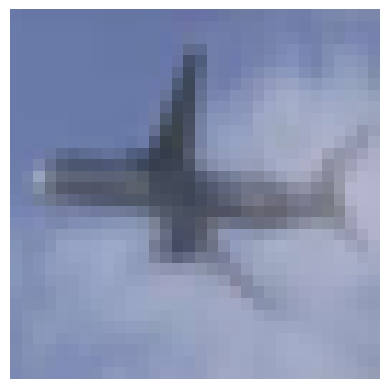

In [5]:
# Task: Display 1 random image
import matplotlib.pyplot as plt
import random

random_num = random.randint(0, 49999)
img = x_train[random_num]
plt.imshow(img)
plt.axis('off')

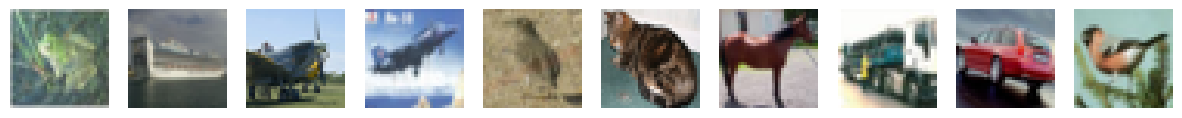

In [6]:
# Task: Display 10 random images in a grid
# create the grid
fig, axes = plt.subplots(1, 10, figsize=(15, 3))

# loop the images into the axes
for i in range(10):
    random_num = random.randint(0, 49999)
    img = x_train[random_num]
    axes[i].imshow(img)
    axes[i].axis('off')

> 2. From 1 to 9, each classes stands for  
'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'

**Questions to Explore:**
1. Do the images seem evenly distributed across the classes?
2. What do you notice about the resolution and quality of the images? How might this affect model training?

> **Answer:**
> 1. The images are evenly distributed across the classes.  
> 2. The resolution and quality of the images are pretty low($32 \times 32$ pixels).  
> Affect:  
>     1. Training Speed & Hardware: you can use very large batch sizes and train the model quickly even on modest GPUs  
>     2. Overfitting Risk: The images are simple, complex models can easily "memorize" the noise in the dataset


## 4. Data Preprocessing

Pixel values range from 0 to 255. You need to scale these values to be between 0 and 1.

**Tasks:**
1. Write a function to normalize the images.
2. Verify that your normalization is correct. What are the maximum and minimum pixel values after normalization?


In [7]:
# Task: Normalize the images
def normalize_images(images):
    return images.astype('float32') / 255.0

In [8]:
# Task: Verify the normalization
print("\nAfter normalization")
print(f"Max pixel value:{np.max(normalize_images(x_train))}")
print(f"Min pixel value:{np.min(normalize_images(x_train))}")


After normalization
Max pixel value:1.0
Min pixel value:0.0


**Questions to Explore:**
1. How would training be affected if the data wasn’t normalized?
2. Are there other preprocessing steps you think might be useful for this dataset?

> **Answer:**
> 1. Affect:
>    1. Slow Convergence
>    2. Vanishing and Exploding Gradients
>    3. Poor Local Minima
> 2. Steps:
>    1. Advanced Data Augmentation (Rotation,Random Cropping & Padding)
>    2. Per-Channel Standardization (use the specific Mean and Standard Deviation of the entire CIFAR-10 dataset)
>    3. Grayscale Conversion
>    4. Color Jittering




---

# Chapter 2: Splitting Data for Model Training and Evaluation

**Objective:** To learn the importance of splitting data into training, validation, and test sets.

## 1. Why Do We Split Data?

**Tasks:**
1. Research and write down the purpose of each of the following sets:
    *   **Training Set**
    *   **Validation Set**
    *   **Test Set**
2. Think about the challenges that might arise if the data is not split properly.

> **Answer:**
> *   **Training Set:** The model adjusts its weights based on the errors it makes on this data
> *   **Validation Set:** To choose the best "Hyperparameters" (like the size of the neural network or the learning rate) and detect Overfitting
> *   **Test Set:** Provides an unbiased final score of the model's performance on real-world, unseen data.
> *   **Challenges of improper splitting:**
>     1. If the Training Set is too small relative to the model's complexity, the model will memorize specific examples instead of general features
>     2. This occurs when information from the Test/Validation Set accidentally "leaks" into the Training Set.


## 2. Choosing Split Ratios

Common split ratios: Train (70-80%), Val (10-20%), Test (10-20%).

**Tasks:**
1. What factors influence the choice of split ratios?
2. What might happen if the validation set is too small or too large?
3. Decide on the split ratios you would like to use for the CIFAR-10 dataset and justify your choice.

**Answer:**
> 1. **Factors influencing Split Ratios:**
>    - **Dataset Size:** Larger datasets (like CIFAR-10 with 60,000 images) can afford a smaller validation/test percentage, while smaller datasets may need a larger proportion for validation to get reliable estimates.
>    - **Model Complexity:** More complex models (e.g., deep neural networks) typically need more training data to learn effectively, so the training set should be larger.
>    - **Task Difficulty:** If the classification task is harder, the model may need more training data to capture subtle patterns.
>    - **Computational Resources:** Larger training sets require more time and memory to train, which may influence the ratio choice.
>
> 2. **Effect of Validation Set size:**
>    - **Too Small:** The validation metrics (accuracy, loss) will have high variance — small changes in the data can cause large swings in the score, making it unreliable for tuning hyperparameters or detecting overfitting.
>    - **Too Large:** Too much data is "wasted" on validation instead of being used for training. The model sees fewer examples during training, which can lead to underfitting and weaker generalization.
>
> 3. **My Choice and Justification:**
>    - **Train: 80%, Validation: 10%, Test: 10%**
>    - CIFAR-10 already provides a separate test set of 10,000 images, so we only need to split the 50,000 training images into training and validation sets.
>    - With 50,000 images, using 10% (5,000 images) for validation is more than enough to get a stable performance estimate, while the remaining 45,000 images give the model plenty of data to learn from.


## 3. Shuffling the Data

Shuffling ensures that the data is randomly distributed.

**Tasks:**
1. Why is shuffling important before splitting the data?
2. Imagine that the CIFAR-10 dataset is sorted by class. What would happen if you split the dataset without shuffling?
3. Find out how to shuffle data in TensorFlow or another library you are using.

> **Answer:**
> 1. **Importance of shuffling:**
>    - Shuffling ensures that each split (training, validation, test) contains a **representative mix** of all classes and data patterns.
>    - Without shuffling, the split may introduce **selection bias** — certain classes or patterns might be concentrated in one split, causing the model to train on an unbalanced or incomplete view of the data.
>
> 2. **Consequences of not shuffling sorted data:**
>    - If CIFAR-10 is sorted by class (e.g., all 5,000 airplanes first, then all 5,000 automobiles, etc.), and you take the first 80% as training data, the training set would contain **only the first 8 classes** (airplane through ship), while the validation/test set would contain **only the last 2 classes** (ship and truck).
>    - The model would **never see** certain classes during training, so it would completely fail to recognize them during validation or testing.
>    - Even the validation metrics would be meaningless, since the validation set would not reflect the true distribution of the full dataset.


In [9]:
# Task: Shuffle the dataset
index = np.random.permutation(len(x_train))
x_train = x_train[index]
y_train = y_train[index]

print("First 10 labels after shuffling:", y_train[:10].flatten())

First 10 labels after shuffling: [1 7 7 9 7 1 2 7 9 5]
